# Cross-Sectional Momentum on Nifty 200
### A backtested systematic equity strategy in Python

**Hypothesis.** Stocks that have gone up the most over the past year tend to keep
outperforming over the next month (the *momentum* effect). By buying the top 10% of
stocks by past return and rebalancing monthly, we aim to beat the Nifty index after costs.

**Method (in one line).** Each month, rank every stock by its return over the past 12
months (skipping the most recent month), buy the top decile equally, hold one month,
repeat. We subtract realistic trading costs and compare against the Nifty.

**What we measure.** CAGR (yearly growth), Sharpe ratio (return per unit of risk),
maximum drawdown (worst peak-to-trough fall), turnover (how much we trade), and an
equity curve versus the Nifty.

> This is an educational backtest, not investment advice.


## 0. Setup

Run this cell **once**. It installs the free tools we need.
`yfinance` downloads stock prices from Yahoo Finance. `pandas` and `numpy` handle the
numbers. `matplotlib` draws the chart. The `!` tells the notebook to install, not to run Python.


In [8]:
!pip install yfinance pandas numpy matplotlib --quiet



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Imports and settings
We load the tools and set our strategy choices in one place so they are easy to change.


In [9]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---- Strategy settings (change these to experiment) ----
START        = '2010-01-01'   # backtest start date
END          = '2025-01-01'   # backtest end date
LOOKBACK     = 12             # months of past return we look at
SKIP         = 1              # skip the most recent month (avoids short-term reversal)
TOP_PCT      = 0.10           # buy the top 10% (top decile)
COST         = 0.0020         # 0.20% one-way trading cost (brokerage + slippage)
BENCHMARK    = '^NSEI'        # Nifty 50 index (market proxy)


## 2. The stock universe (Nifty 200)

Below is a representative list of large Nifty-listed companies. `.NS` tells Yahoo the
stock trades on India's NSE exchange.

The official Nifty 200 list changes over time. To use the exact current list:
1. Go to **niftyindices.com**  →  Products  →  Equity  →  search 'Nifty 200'.
2. Download the CSV of constituents.
3. Add `.NS` to each symbol and replace the list below.

Any ticker that fails to download is dropped automatically, so a few stale names are fine.


In [10]:
tickers = ["RELIANCE", "TCS", "HDFCBANK", "ICICIBANK", "INFY", "HINDUNILVR", "ITC", "SBIN", "BHARTIARTL", "KOTAKBANK", "LT", "AXISBANK", "BAJFINANCE", "ASIANPAINT", "MARUTI", "HCLTECH", "SUNPHARMA", "TITAN", "ULTRACEMCO", "WIPRO", "NESTLEIND", "ONGC", "NTPC", "POWERGRID", "TATAMOTORS", "TATASTEEL", "JSWSTEEL", "ADANIENT", "ADANIPORTS", "COALINDIA", "BAJAJFINSV", "BAJAJ-AUTO", "HEROMOTOCO", "EICHERMOT", "M&M", "DRREDDY", "CIPLA", "DIVISLAB", "APOLLOHOSP", "GRASIM", "BRITANNIA", "DABUR", "GODREJCP", "MARICO", "PIDILITIND", "BERGEPAINT", "HAVELLS", "DMART", "SBILIFE", "HDFCLIFE", "ICICIPRULI", "ICICIGI", "SHREECEM", "AMBUJACEM", "ACC", "VEDL", "HINDALCO", "JINDALSTEL", "SAIL", "NMDC", "TATAPOWER", "GAIL", "IOC", "BPCL", "INDUSINDBK", "BANKBARODA", "PNB", "CANBK", "IDFCFIRSTB", "FEDERALBNK", "AUBANK", "CHOLAFIN", "MUTHOOTFIN", "LICHSGFIN", "SIEMENS", "ABB", "BOSCHLTD", "BEL", "HAL", "BHEL", "LTIM", "MPHASIS", "PERSISTENT", "COFORGE", "TATAELXSI", "NAUKRI", "PAYTM", "TRENT", "PAGEIND", "COLPAL", "TORNTPHARM", "LUPIN", "AUROPHARMA", "BIOCON", "ALKEM", "ZYDUSLIFE", "GLENMARK", "INDIGO", "DLF", "GODREJPROP", "OBEROIRLTY", "PRESTIGE", "TVSMOTOR", "ASHOKLEY", "BALKRISIND", "MOTHERSON", "BHARATFORG", "CUMMINSIND", "TATACONSUM", "VOLTAS", "PIIND", "SRF", "UPL", "DEEPAKNTR", "NAVINFLUOR", "TATACOMM", "PETRONET", "IGL", "TORNTPOWER", "NHPC", "IRCTC", "CONCOR", "RECLTD", "PFC", "POLYCAB"]
tickers = [t + '.NS' for t in tickers]
print('Universe size:', len(tickers))


Universe size: 125


## 3. Download the price data

We download daily prices, then keep only the last price of each month (monthly data is
all momentum needs). `auto_adjust=True` adjusts for splits and dividends so returns are
correct. This step needs internet and may take 1-2 minutes.


In [11]:
raw = yf.download(tickers, start=START, end=END, auto_adjust=True, progress=False)
prices = raw['Close']                       # adjusted closing prices
prices = prices.resample('ME').last()       # keep month-end prices
prices = prices.dropna(axis=1, how='all')   # drop tickers that failed
prices = prices.dropna(axis=1, thresh=int(len(prices)*0.6))  # need enough history
print('Stocks with usable data:', prices.shape[1])
print('Months of data:', prices.shape[0])

bench_raw = yf.download(BENCHMARK, start=START, end=END, auto_adjust=True, progress=False)['Close']
benchmark = bench_raw.resample('ME').last()
benchmark = benchmark.squeeze()             # make it a single column
prices.tail()


$TATAMOTORS.NS: possibly delisted; no timezone found
$LTIM.NS: possibly delisted; no timezone found

2 Failed downloads:
['TATAMOTORS.NS', 'LTIM.NS']: possibly delisted; no timezone found


Stocks with usable data: 113
Months of data: 180


Ticker,ABB.NS,ACC.NS,ADANIENT.NS,ADANIPORTS.NS,ALKEM.NS,AMBUJACEM.NS,APOLLOHOSP.NS,ASHOKLEY.NS,ASIANPAINT.NS,AUROPHARMA.NS,...,TORNTPHARM.NS,TORNTPOWER.NS,TRENT.NS,TVSMOTOR.NS,ULTRACEMCO.NS,UPL.NS,VEDL.NS,VOLTAS.NS,WIPRO.NS,ZYDUSLIFE.NS
Date,,,,,,,,,,,,,,,,,,,,,
2024-08-31,7840.784668,2306.440430,3016.505371,1468.536133,6063.045898,611.771179,6899.712402,121.931938,3061.532471,1563.530884,...,3421.304688,1694.859131,7144.062500,2791.923584,11230.711914,587.239624,410.941864,1728.540649,249.498810,1114.124634
2024-09-30,7958.307129,2488.943604,3132.895508,1435.140015,5947.540527,627.138611,7170.272949,111.923485,3259.609863,1455.237305,...,3334.328125,1825.606812,7559.109375,2818.271973,11727.662109,601.764893,470.145782,1829.111450,250.912201,1055.499634
2024-10-31,7340.266113,2297.775879,2944.473145,1363.541504,5678.747559,575.583496,6994.530762,98.981438,2874.372314,1391.277466,...,3143.979736,1770.926147,7113.725098,2474.751953,10995.950195,543.369629,425.575195,1635.206421,255.708450,989.021423
2024-11-30,7332.164551,2200.879883,2460.829102,1179.318115,5544.326660,526.953125,6801.507812,111.356133,2432.003418,1257.878174,...,3263.303467,1468.553955,6781.457520,2415.952148,11131.590820,534.880249,415.899902,1643.880615,267.780212,954.152649
2024-12-31,6829.274902,2032.487915,2526.267334,1219.997803,5535.925293,531.216309,7267.083008,105.799843,2237.558838,1329.509399,...,3298.496826,1444.494385,7108.735352,2350.503418,11354.377930,491.697296,415.055817,1774.439331,279.759308,959.832397


## 4. Build the momentum signal

For each stock and each month we compute the return over the past 12 months, **excluding
the most recent month**. In code, `shift(1)` means 'one month ago' and `shift(12)` means
'twelve months ago'. So the signal is *price one month ago ÷ price twelve months ago − 1*.
We also compute each stock's **next**-month return, which is what we actually earn.


In [12]:
momentum   = prices.shift(SKIP) / prices.shift(LOOKBACK) - 1   # 12-1 momentum signal
fwd_return = prices.pct_change().shift(-1)                     # next month's return
momentum.tail(3)


Ticker,ABB.NS,ACC.NS,ADANIENT.NS,ADANIPORTS.NS,ALKEM.NS,AMBUJACEM.NS,APOLLOHOSP.NS,ASHOKLEY.NS,ASIANPAINT.NS,AUROPHARMA.NS,...,TORNTPHARM.NS,TORNTPOWER.NS,TRENT.NS,TVSMOTOR.NS,ULTRACEMCO.NS,UPL.NS,VEDL.NS,VOLTAS.NS,WIPRO.NS,ZYDUSLIFE.NS
Date,,,,,,,,,,,,,,,,,,,,,
2024-10-31,0.969866,0.334934,0.367126,0.853346,0.638518,0.494780,0.497276,0.444200,0.124004,0.727107,...,0.783609,1.616035,2.517016,0.792229,0.409598,0.136378,1.668248,1.211144,0.421176,0.867693
2024-11-30,0.689266,0.240714,0.250091,0.673959,0.232698,0.325675,0.273269,0.169462,-0.049952,0.342725,...,0.521798,0.913527,1.558884,0.342751,0.236307,-0.028110,1.241923,0.999540,0.338765,0.574382
2024-12-31,0.595322,0.007978,-0.135080,0.166746,0.092700,0.023430,0.200113,0.327263,-0.262908,0.166441,...,0.456920,0.638038,1.225407,0.206474,0.072887,-0.070338,0.894292,0.701131,0.228692,0.405048


## 5. Run the backtest

Each month we: (a) rank stocks by momentum, (b) pick the top decile to go long and the
bottom decile for a market-neutral 'long-short' spread, (c) earn next month's return,
(d) subtract trading costs based on how much the holdings changed (turnover).

There is **no look-ahead**: the signal at each month uses only past prices, and we earn
the *following* month's return. This is the walk-forward discipline that makes the test honest.


In [13]:
long_ret, ls_ret, turnovers, out_dates = [], [], [], []
prev = set()

for t in range(LOOKBACK, len(prices) - 1):
    sig = momentum.iloc[t].dropna()
    if len(sig) < 20:               # need enough stocks to form deciles
        continue
    k = max(1, int(len(sig) * TOP_PCT))
    winners = sig.nlargest(k).index
    losers  = sig.nsmallest(k).index

    r_win = fwd_return.iloc[t][winners].mean()   # equal-weight top decile
    r_los = fwd_return.iloc[t][losers].mean()    # equal-weight bottom decile

    cur = set(winners)
    turnover = len(cur.symmetric_difference(prev)) / (2*k) if prev else 1.0
    turnovers.append(turnover)

    long_ret.append(r_win - turnover*COST)              # long-only, net of costs
    ls_ret.append((r_win - r_los) - 2*turnover*COST)    # long-short spread, net of costs
    out_dates.append(prices.index[t+1])
    prev = cur

long_only = pd.Series(long_ret, index=out_dates)
long_short = pd.Series(ls_ret, index=out_dates)
bmk = benchmark.pct_change().reindex(out_dates).fillna(0)
print('Backtest months:', len(long_only))


Backtest months: 167


## 6. Performance metrics
CAGR = yearly compounded growth. Sharpe = return divided by risk (higher is better;
we assume a 0% risk-free rate for simplicity). Max drawdown = worst fall from a peak.


In [14]:
def metrics(r):
    r = r.dropna()
    equity = (1 + r).cumprod()
    years  = len(r) / 12
    cagr   = equity.iloc[-1]**(1/years) - 1
    sharpe = (r.mean() / r.std()) * np.sqrt(12)
    maxdd  = (equity / equity.cummax() - 1).min()
    return {'CAGR': cagr, 'Sharpe': sharpe, 'MaxDD': maxdd}

table = pd.DataFrame({
    'Long-only top decile': metrics(long_only),
    'Nifty (benchmark)'   : metrics(bmk),
    'Long-short spread'   : metrics(long_short),
}).T
table['Avg turnover/month'] = [np.mean(turnovers), np.nan, np.mean(turnovers)]
table_fmt = table.copy()
for c in ['CAGR','MaxDD','Avg turnover/month']:
    table_fmt[c] = (table_fmt[c]*100).round(1).astype(str) + '%'
table_fmt['Sharpe'] = table['Sharpe'].round(2)
print(table_fmt)
table.to_csv('metrics.csv')


                       CAGR  Sharpe   MaxDD Avg turnover/month
Long-only top decile  31.9%    1.42  -22.7%              27.2%
Nifty (benchmark)     11.0%    0.72  -29.3%                NaN
Long-short spread      8.0%    0.45  -39.0%              27.2%


## 7. Equity curve vs Nifty
This chart shows how one rupee would have grown in each approach. Save it for your README.


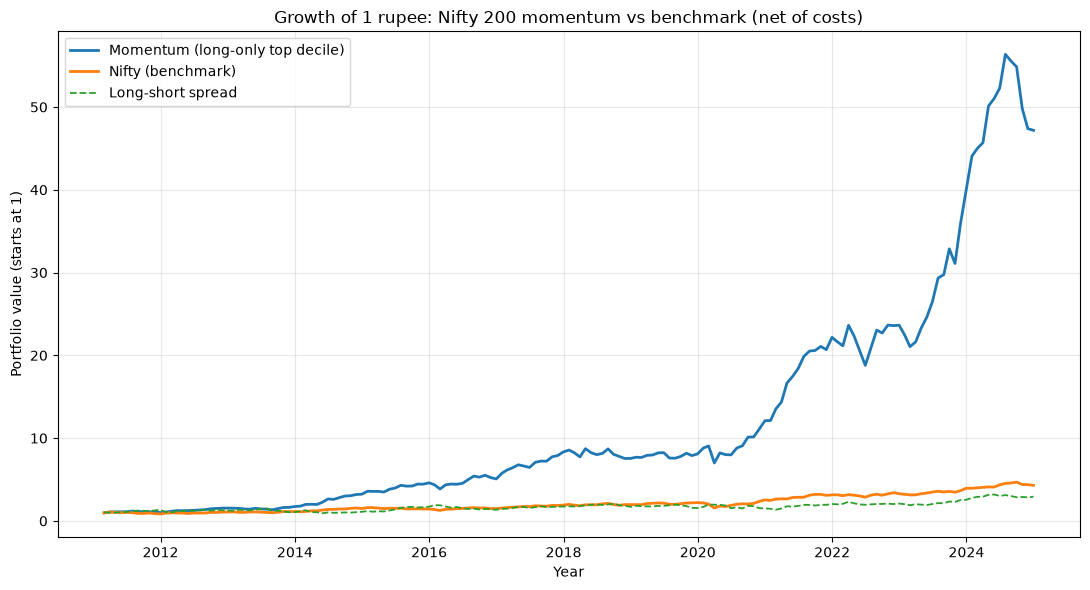

In [15]:
eq_long  = (1 + long_only).cumprod()
eq_bmk   = (1 + bmk).cumprod()
eq_ls    = (1 + long_short).cumprod()

plt.figure(figsize=(11,6))
plt.plot(eq_long.index, eq_long, label='Momentum (long-only top decile)', linewidth=2)
plt.plot(eq_bmk.index,  eq_bmk,  label='Nifty (benchmark)', linewidth=2)
plt.plot(eq_ls.index,   eq_ls,   label='Long-short spread', linewidth=1.3, linestyle='--')
plt.title('Growth of 1 rupee: Nifty 200 momentum vs benchmark (net of costs)')
plt.ylabel('Portfolio value (starts at 1)')
plt.xlabel('Year')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('equity_curve.png', dpi=150)
plt.show()


## 8. What the results mean, and the limitations

Read the metrics table and the chart together. A good momentum result usually shows a
**higher Sharpe** than the Nifty even if raw returns are similar, because it delivers
return more smoothly.

**Honest limitations to state in interviews:**
- **Survivorship bias:** our universe is today's list, so failed/delisted firms are missing.
- **Cost simplicity:** a flat 0.20% cost ignores market impact on illiquid names.
- **No short-selling realism:** the long-short spread assumes shorting is free and possible.
- **Point-in-time membership:** stocks entered/left the Nifty 200 over the years.
- **Single factor:** real quant funds combine momentum with value, quality, and risk controls.

These limitations are strengths in an interview: naming them shows you understand backtesting.
